In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Matplotlib is building the font cache; this may take a moment.


In [7]:
DATA_PATH = "/Users/vaibhav/Desktop/Projects/AI-Revenue-Recovery/data/raw/default of credit card clients.xls"

df = pd.read_excel(DATA_PATH)

df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [8]:
print(df.shape)
print(df.columns.tolist())
df.head()

(30001, 25)
['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'Y']


,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [9]:
df = df.drop(columns=["Unnamed: 0"])

In [10]:
df.shape

(30001, 24)

In [11]:
df = df.rename(columns={
    "X1": "credit_limit",
    "X2": "gender",
    "X3": "education",
    "X4": "marital_status",
    "X5": "age",

    "X6": "pay_status_1",
    "X7": "pay_status_2",
    "X8": "pay_status_3",
    "X9": "pay_status_4",
    "X10": "pay_status_5",
    "X11": "pay_status_6",

    "X12": "bill_amount_1",
    "X13": "bill_amount_2",
    "X14": "bill_amount_3",
    "X15": "bill_amount_4",
    "X16": "bill_amount_5",
    "X17": "bill_amount_6",

    "X18": "payment_amount_1",
    "X19": "payment_amount_2",
    "X20": "payment_amount_3",
    "X21": "payment_amount_4",
    "X22": "payment_amount_5",
    "X23": "payment_amount_6",

    "Y": "default_next_month"
})

In [12]:
df.columns.tolist()

['credit_limit',
 'gender',
 'education',
 'marital_status',
 'age',
 'pay_status_1',
 'pay_status_2',
 'pay_status_3',
 'pay_status_4',
 'pay_status_5',
 'pay_status_6',
 'bill_amount_1',
 'bill_amount_2',
 'bill_amount_3',
 'bill_amount_4',
 'bill_amount_5',
 'bill_amount_6',
 'payment_amount_1',
 'payment_amount_2',
 'payment_amount_3',
 'payment_amount_4',
 'payment_amount_5',
 'payment_amount_6',
 'default_next_month']

In [13]:
df.head()

,credit_limit,gender,education,marital_status,age,pay_status_1,pay_status_2,pay_status_3,pay_status_4,pay_status_5,pay_status_6,bill_amount_1,bill_amount_2,bill_amount_3,bill_amount_4,bill_amount_5,bill_amount_6,payment_amount_1,payment_amount_2,payment_amount_3,payment_amount_4,payment_amount_5,payment_amount_6,default_next_month
0,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [16]:
df = df.iloc[1:].reset_index(drop=True)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   credit_limit        30001 non-null  object
 1   gender              30001 non-null  object
 2   education           30001 non-null  object
 3   marital_status      30001 non-null  object
 4   age                 30001 non-null  object
 5   pay_status_1        30001 non-null  object
 6   pay_status_2        30001 non-null  object
 7   pay_status_3        30001 non-null  object
 8   pay_status_4        30001 non-null  object
 9   pay_status_5        30001 non-null  object
 10  pay_status_6        30001 non-null  object
 11  bill_amount_1       30001 non-null  object
 12  bill_amount_2       30001 non-null  object
 13  bill_amount_3       30001 non-null  object
 14  bill_amount_4       30001 non-null  object
 15  bill_amount_5       30001 non-null  object
 16  bill_amount_6       30001 non-nul

In [17]:
df.shape

(30000, 24)

In [20]:
df = df.apply(pd.to_numeric, errors="coerce")


In [21]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   credit_limit        30000 non-null  int64
 1   gender              30000 non-null  int64
 2   education           30000 non-null  int64
 3   marital_status      30000 non-null  int64
 4   age                 30000 non-null  int64
 5   pay_status_1        30000 non-null  int64
 6   pay_status_2        30000 non-null  int64
 7   pay_status_3        30000 non-null  int64
 8   pay_status_4        30000 non-null  int64
 9   pay_status_5        30000 non-null  int64
 10  pay_status_6        30000 non-null  int64
 11  bill_amount_1       30000 non-null  int64
 12  bill_amount_2       30000 non-null  int64
 13  bill_amount_3       30000 non-null  int64
 14  bill_amount_4       30000 non-null  int64
 15  bill_amount_5       30000 non-null  int64
 16  bill_amount_6       30000 non-null  int64
 17  paym

In [22]:
df.isnull().sum().sum()

np.int64(0)

In [23]:
df["default_next_month"].value_counts()

default_next_month
0    23364
1     6636
Name: count, dtype: int64

In [19]:
df["default_next_month"].value_counts(normalize=True)

default_next_month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [24]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 35


In [25]:
print("Gender:")
print(df["gender"].value_counts().sort_index())

print("\nEducation:")
print(df["education"].value_counts().sort_index())

print("\nMarital Status:")
print(df["marital_status"].value_counts().sort_index())

Gender:
gender
1    11888
2    18112
Name: count, dtype: int64

Education:
education
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

Marital Status:
marital_status
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [26]:
payment_status_cols = [
    "pay_status_1",
    "pay_status_2",
    "pay_status_3",
    "pay_status_4",
    "pay_status_5",
    "pay_status_6"
]

for col in payment_status_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())


pay_status_1:
pay_status_1
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

pay_status_2:
pay_status_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

pay_status_3:
pay_status_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

pay_status_4:
pay_status_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

pay_status_5:
pay_status_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

pay_status_6:
pay_status_6
-2     4895
-1     5740
 0    16286
 2     2766
 3    

In [27]:
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates().reset_index(drop=True)

print("After removing duplicates:", df.shape)

Before removing duplicates: (30000, 24)
After removing duplicates: (29965, 24)


In [ ]:
# Clean education
df["education"] = df["education"].replace({
    0: 4,
    5: 4,
    6: 4
})

In [ ]:
print(df["education"].value_counts().sort_index())

education
1    10563
2    14019
3     4915
4      468
Name: count, dtype: int64


In [30]:
#  Clean marital status
df["marital_status"] = df["marital_status"].replace({
    0: 3
})

In [31]:
print(df["marital_status"].value_counts().sort_index())

marital_status
1    13643
2    15945
3      377
Name: count, dtype: int64


# In this dataset:

* -2 = no consumption / no payment information in that month
* -1 = paid duly
* 0 = revolving credit / no payment delay
* 1 = payment delay of 1 month
* 2 = payment delay of 2 months
* 3 = payment delay of 3 months
* etc.

In [ ]:
payment_status_cols = [
    "pay_status_1",
    "pay_status_2",
    "pay_status_3",
    "pay_status_4",
    "pay_status_5",
    "pay_status_6"
]

df["num_delayed_payments"] = (
    df[payment_status_cols] > 0
).sum(axis=1)

#0 → no delayed payments
#1 → delayed in 1 of the 6 months
#2 → delayed in 2 months
#3 → delayed in 3 months
#4 → delayed in 4 months
#5 → delayed in 5 months
#6 → delayed in all 6 months

In [33]:
# Maximum delay
df["max_payment_delay"] = df[payment_status_cols].clip(lower=0).max(axis=1) # This converts -2 and -1 to 0, because neither represents an actual delay.

In [ ]:
#Average delay
delay_data = df[payment_status_cols].clip(lower=0)

df["avg_payment_delay"] = delay_data.mean(axis=1)

In [35]:
# Recent payment delay
df["recent_payment_delay"] = df["pay_status_1"].clip(lower=0)

In [36]:
df[
    [
        "num_delayed_payments",
        "max_payment_delay",
        "avg_payment_delay",
        "recent_payment_delay"
    ]
].describe()

,num_delayed_payments,max_payment_delay,avg_payment_delay,recent_payment_delay
count,29965.000000,29965.000000,29965.000000,29965.000000
mean,0.834273,0.682163,0.281384,0.356416
std,1.554821,1.073847,0.601610,0.760752
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,1.000000,2.000000,0.333333,0.000000
max,6.000000,8.000000,6.000000,8.000000


In [37]:
df[
    [
        "num_delayed_payments",
        "max_payment_delay",
        "avg_payment_delay",
        "recent_payment_delay"
    ]
].head(10)

,num_delayed_payments,max_payment_delay,avg_payment_delay,recent_payment_delay
0,2,2,0.666667,2
1,2,2,0.666667,0
2,0,0,0.000000,0
3,0,0,0.000000,0
4,0,0,0.000000,0
5,0,0,0.000000,0
6,0,0,0.000000,0
7,0,0,0.000000,0
8,1,2,0.333333,0
9,0,0,0.000000,0


# Average bill and payment

In [38]:
bill_cols = [
    "bill_amount_1",
    "bill_amount_2",
    "bill_amount_3",
    "bill_amount_4",
    "bill_amount_5",
    "bill_amount_6"
]

payment_cols = [
    "payment_amount_1",
    "payment_amount_2",
    "payment_amount_3",
    "payment_amount_4",
    "payment_amount_5",
    "payment_amount_6"
]

df["avg_bill_amount"] = df[bill_cols].mean(axis=1)
df["avg_payment_amount"] = df[payment_cols].mean(axis=1)

# Total bill/payment

In [39]:
df["total_bill_amount"] = df[bill_cols].sum(axis=1)
df["total_payment_amount"] = df[payment_cols].sum(axis=1)

# Payment-to-bill ratio
This tells us roughly how much the customer has been paying relative to their billed amounts.

In [40]:
df["payment_to_bill_ratio"] = np.where(
    df["total_bill_amount"] > 0,
    df["total_payment_amount"] / df["total_bill_amount"],
    0
)

In [41]:
# Let’s prevent extreme outliers from dominating:
df["payment_to_bill_ratio"] = df["payment_to_bill_ratio"].clip(0, 5)

# Credit utilization

In [42]:
df["credit_utilization"] = np.where(
    df["credit_limit"] > 0,
    df["avg_bill_amount"] / df["credit_limit"],
    0
)

In [ ]:
# Cap extreme values
df["credit_utilization"] = df["credit_utilization"].clip(0, 5)

In [44]:
df[
    [
        "avg_bill_amount",
        "avg_payment_amount",
        "total_bill_amount",
        "total_payment_amount",
        "payment_to_bill_ratio",
        "credit_utilization"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
avg_bill_amount,29965.0,45029.328116,63279.074163,-56043.166667,4841.000000,21110.833333,57166.166667,8.773138e+05
avg_payment_amount,29965.0,5281.297308,10142.306855,0.000000,1116.666667,2400.000000,5600.000000,6.273443e+05
total_bill_amount,29965.0,270175.968697,379674.444976,-336259.000000,29046.000000,126665.000000,342997.000000,5.263883e+06
total_payment_amount,29965.0,31687.783848,60853.841129,0.000000,6700.000000,14400.000000,33600.000000,3.764066e+06
payment_to_bill_ratio,29965.0,0.370652,0.590891,0.000000,0.040995,0.085097,0.587641,5.000000e+00
credit_utilization,29965.0,0.373560,0.351592,0.000000,0.030300,0.285629,0.688454,5.000000e+00


In [45]:
df[
    [
        "avg_bill_amount",
        "avg_payment_amount",
        "payment_to_bill_ratio",
        "credit_utilization"
    ]
].head(10)

,avg_bill_amount,avg_payment_amount,payment_to_bill_ratio,credit_utilization
0,1284.000000,114.833333,0.089434,0.064200
1,2846.166667,833.333333,0.292791,0.023718
2,16942.166667,1836.333333,0.108388,0.188246
3,38555.666667,1398.000000,0.036259,0.771113
4,18223.166667,9841.500000,0.540054,0.364463
5,39685.666667,1295.333333,0.032640,0.793713
6,454099.166667,30126.500000,0.066343,0.908198
7,2247.666667,798.500000,0.355257,0.022477
8,10868.666667,1126.833333,0.103677,0.077633
9,4486.500000,2354.833333,0.524871,0.224325


# Fix credit utilization

In [46]:
# Calculate positive bill amounts
positive_bill_cols = df[bill_cols].clip(lower=0)

df["avg_positive_bill"] = positive_bill_cols.mean(axis=1)

In [47]:
#  Recalculate utilization
df["credit_utilization"] = np.where(
    df["credit_limit"] > 0,
    df["avg_positive_bill"] / df["credit_limit"],
    0
)

df["credit_utilization"] = df["credit_utilization"].clip(0, 5)

In [48]:
df[
    [
        "credit_limit",
        "avg_positive_bill",
        "credit_utilization"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
credit_limit,29965.0,167442.005006,129760.135222,10000.0,50000.000000,140000.000000,240000.000000,1000000.000000
avg_positive_bill,29965.0,45066.883659,63267.538151,0.0,4868.500000,21118.500000,57176.333333,877313.833333
credit_utilization,29965.0,0.373794,0.351541,0.0,0.030531,0.285678,0.688706,5.000000


# Payment behavior features

In [ ]:
# Higher value = payments vary a lot month-to-month.
df["payment_std"] = df[payment_cols].std(axis=1)

# Recent payment amount

In [50]:
df["recent_payment_amount"] = df["payment_amount_1"]

In [52]:
#Recent bill amount
df["recent_bill_amount"] = df["bill_amount_1"]

In [53]:
# Recent payment ratio

df["recent_payment_ratio"] = np.where(
    df["recent_bill_amount"] > 0,
    df["recent_payment_amount"] / df["recent_bill_amount"],
    0
)

df["recent_payment_ratio"] = df["recent_payment_ratio"].clip(0, 5)

In [54]:
df[
    [
        "payment_std",
        "recent_payment_amount",
        "recent_bill_amount",
        "recent_payment_ratio"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
payment_std,29965.0,5811.698835,15013.888412,0.0,617.271415,1416.175942,4132.405337,650098.33882
recent_payment_amount,29965.0,5670.099316,16571.849467,0.0,1000.000000,2102.000000,5008.000000,873552.00000
recent_bill_amount,29965.0,51283.009778,73658.132403,-165580.0,3595.000000,22438.000000,67260.000000,964511.00000
recent_payment_ratio,29965.0,0.425832,1.004476,0.0,0.031817,0.052694,0.215564,5.00000


In [55]:
df[
    [
        "payment_std",
        "recent_payment_amount",
        "recent_bill_amount",
        "recent_payment_ratio"
    ]
].head(10)

,payment_std,recent_payment_amount,recent_bill_amount,recent_payment_ratio
0,281.283072,0,3913,0.000000
1,752.772653,0,2682,0.000000
2,1569.815488,1518,29239,0.051917
3,478.058155,2000,46990,0.042562
4,13786.230736,2000,8617,0.232099
5,713.938840,2500,64400,0.038820
6,16802.717087,55000,367965,0.149471
7,669.519455,380,11876,0.031997
8,1153.286160,3329,11285,0.294993
9,5237.737925,0,0,0.000000


# Basic EDA

In [56]:
# Correlation with default
correlation = (
    df.corr(numeric_only=True)["default_next_month"]
    .sort_values(ascending=False)
)

correlation

default_next_month       1.000000
num_delayed_payments     0.398406
recent_payment_delay     0.396200
avg_payment_delay        0.376004
max_payment_delay        0.370398
pay_status_1             0.324964
pay_status_2             0.263656
pay_status_3             0.235230
pay_status_4             0.216551
pay_status_5             0.204059
pay_status_6             0.186740
credit_utilization       0.115736
education                0.033862
age                      0.013619
bill_amount_6           -0.005469
bill_amount_5           -0.006859
bill_amount_4           -0.010259
avg_positive_bill       -0.012784
avg_bill_amount         -0.012802
total_bill_amount       -0.012802
bill_amount_3           -0.014182
bill_amount_2           -0.014302
recent_bill_amount      -0.019758
bill_amount_1           -0.019758
marital_status          -0.027259
gender                  -0.039742
payment_amount_6        -0.053250
payment_amount_5        -0.055194
payment_amount_3        -0.056319
payment_amount

In [57]:
# Focus on our engineered features
engineered_cols = [
    "num_delayed_payments",
    "max_payment_delay",
    "avg_payment_delay",
    "recent_payment_delay",
    "avg_bill_amount",
    "avg_payment_amount",
    "payment_to_bill_ratio",
    "credit_utilization",
    "payment_std",
    "recent_payment_amount",
    "recent_bill_amount",
    "recent_payment_ratio"
]

df[engineered_cols + ["default_next_month"]].corr()["default_next_month"].sort_values(
    ascending=False
)

default_next_month       1.000000
num_delayed_payments     0.398406
recent_payment_delay     0.396200
avg_payment_delay        0.376004
max_payment_delay        0.370398
credit_utilization       0.115736
avg_bill_amount         -0.012802
recent_bill_amount      -0.019758
recent_payment_ratio    -0.068288
recent_payment_amount   -0.073015
payment_std             -0.074123
payment_to_bill_ratio   -0.088731
avg_payment_amount      -0.102488
Name: default_next_month, dtype: float64

In [58]:
# Default rate by number of delayed payments
df.groupby("num_delayed_payments")["default_next_month"].mean()

num_delayed_payments
0    0.117130
1    0.298751
2    0.387572
3    0.508666
4    0.573081
5    0.573826
6    0.702985
Name: default_next_month, dtype: float64

# Payment behavior score

In [59]:
df["payment_behavior_score"] = (
    1
    - (
        df["avg_payment_delay"] / 8
    )
)

df["payment_behavior_score"] = df["payment_behavior_score"].clip(0, 1)

In [60]:
df["payment_behavior_score"].describe()


count    29965.000000
mean         0.964827
std          0.075201
min          0.250000
25%          0.958333
50%          1.000000
75%          1.000000
max          1.000000
Name: payment_behavior_score, dtype: float64

In [61]:
df[
    [
        "num_delayed_payments",
        "avg_payment_delay",
        "payment_behavior_score",
        "default_next_month"
    ]
].head(10)

,num_delayed_payments,avg_payment_delay,payment_behavior_score,default_next_month
0,2,0.666667,0.916667,1
1,2,0.666667,0.916667,1
2,0,0.000000,1.000000,0
3,0,0.000000,1.000000,0
4,0,0.000000,1.000000,0
5,0,0.000000,1.000000,0
6,0,0.000000,1.000000,0
7,0,0.000000,1.000000,0
8,1,0.333333,0.958333,0
9,0,0.000000,1.000000,0


#  prepare ML target

In [62]:
df["payment_success"] = 1 - df["default_next_month"]

In [63]:
print(df["payment_success"].value_counts())
print()
print(df["payment_success"].value_counts(normalize=True))

payment_success
1    23335
0     6630
Name: count, dtype: int64

payment_success
1    0.778742
0    0.221258
Name: proportion, dtype: float64


In [64]:
pd.crosstab(
    df["default_next_month"],
    df["payment_success"]
)

payment_success,0,1
default_next_month,,
0,0,23335
1,6630,0


# Define features

In [65]:
feature_cols = [
    "credit_limit",
    "gender",
    "education",
    "marital_status",
    "age",

    "pay_status_1",
    "pay_status_2",
    "pay_status_3",
    "pay_status_4",
    "pay_status_5",
    "pay_status_6",

    "bill_amount_1",
    "bill_amount_2",
    "bill_amount_3",
    "bill_amount_4",
    "bill_amount_5",
    "bill_amount_6",

    "payment_amount_1",
    "payment_amount_2",
    "payment_amount_3",
    "payment_amount_4",
    "payment_amount_5",
    "payment_amount_6",

    # Engineered behavioral features
    "num_delayed_payments",
    "max_payment_delay",
    "avg_payment_delay",
    "recent_payment_delay",
    "avg_bill_amount",
    "avg_payment_amount",
    "total_bill_amount",
    "total_payment_amount",
    "payment_to_bill_ratio",
    "credit_utilization",
    "payment_std",
    "recent_payment_amount",
    "recent_bill_amount",
    "recent_payment_ratio",
    "payment_behavior_score"
]

In [66]:
X = df[feature_cols]
y = df["payment_success"]

In [67]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (29965, 38)
y shape: (29965,)

Target distribution:
payment_success
1    23335
0     6630
Name: count, dtype: int64


In [68]:
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

Missing values in X: 0
Missing values in y: 0


# Train/Test Split

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [70]:
print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (23972, 38)
y_train: (23972,)

Testing set:
X_test: (5993, 38)
y_test: (5993,)


In [71]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
payment_success
1    0.778742
0    0.221258
Name: proportion, dtype: float64

Testing target distribution:
payment_success
1    0.778742
0    0.221258
Name: proportion, dtype: float64


# BAseline Logistic Regression

In [72]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [73]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [74]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [75]:
y_pred = logistic_model.predict(X_test_scaled)
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.8239612881695311
Precision: 0.8421750663129973
Recall   : 0.9524319691450611
F1 Score : 0.8939165409753645
ROC-AUC  : 0.7747765107922155

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.37      0.48      1326
           1       0.84      0.95      0.89      4667

    accuracy                           0.82      5993
   macro avg       0.77      0.66      0.69      5993
weighted avg       0.81      0.82      0.80      5993



#  Random Forest Non Linear

In [77]:
from sklearn.ensemble import RandomForestClassifier

In [78]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [79]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [80]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy : 0.8009344234940764
Precision: 0.8727467811158798
Recall   : 0.871437754446111
F1 Score : 0.8720917765626676
ROC-AUC  : 0.7888192213807612

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.55      0.55      1326
           1       0.87      0.87      0.87      4667

    accuracy                           0.80      5993
   macro avg       0.71      0.71      0.71      5993
weighted avg       0.80      0.80      0.80      5993



# XGBoost

In [82]:
from xgboost import XGBClassifier

In [83]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 0.2841225626740947


In [84]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [85]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [86]:
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Accuracy : 0.7717336893041882
Precision: 0.8831591173054588
Recall   : 0.8146560959931434
F1 Score : 0.8475256353098529
ROC-AUC  : 0.7887673504898325

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.62      0.55      1326
           1       0.88      0.81      0.85      4667

    accuracy                           0.77      5993
   macro avg       0.69      0.72      0.70      5993
weighted avg       0.80      0.77      0.78      5993



# Instead of:
payment_success
1 = success
0 = failure 

# We use:
payment_failure
1 = failure
0 = success

ML output = probability of payment failure

In [87]:
# Let’s change the target cleanly
df["payment_failure"] = df["default_next_month"]

In [88]:
X = df[feature_cols]
y = df["payment_failure"]

In [89]:
print(y.value_counts())
print(y.value_counts(normalize=True))

payment_failure
0    23335
1     6630
Name: count, dtype: int64
payment_failure
0    0.778742
1    0.221258
Name: proportion, dtype: float64


# redoing the train/test split

In [91]:
from sklearn.model_selection import train_test_split

X = df[feature_cols]
y = df["payment_failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [92]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nTesting target:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

X_train: (23972, 38)
X_test: (5993, 38)

Training target:
payment_failure
0    18668
1     5304
Name: count, dtype: int64
payment_failure
0    0.778742
1    0.221258
Name: proportion, dtype: float64

Testing target:
payment_failure
0    4667
1    1326
Name: count, dtype: int64
payment_failure
0    0.778742
1    0.221258
Name: proportion, dtype: float64


In [94]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Scale pos weight:", scale_pos_weight)

Scale pos weight: 3.519607843137255


In [95]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [96]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [97]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Accuracy : 0.7645586517603871
Precision: 0.47428917120387176
Recall   : 0.5912518853695324
F1 Score : 0.5263511245384357
ROC-AUC  : 0.7718769926259308

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      4667
           1       0.47      0.59      0.53      1326

    accuracy                           0.76      5993
   macro avg       0.67      0.70      0.68      5993
weighted avg       0.79      0.76      0.77      5993



In [98]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(15)

max_payment_delay         0.240965
num_delayed_payments      0.210147
avg_payment_delay         0.076449
pay_status_1              0.058432
recent_payment_delay      0.052744
payment_behavior_score    0.036970
total_bill_amount         0.017355
avg_bill_amount           0.015960
avg_payment_amount        0.014765
credit_utilization        0.011284
bill_amount_1             0.011188
credit_limit              0.011099
recent_payment_ratio      0.010707
payment_amount_2          0.010544
recent_bill_amount        0.010416
dtype: float32

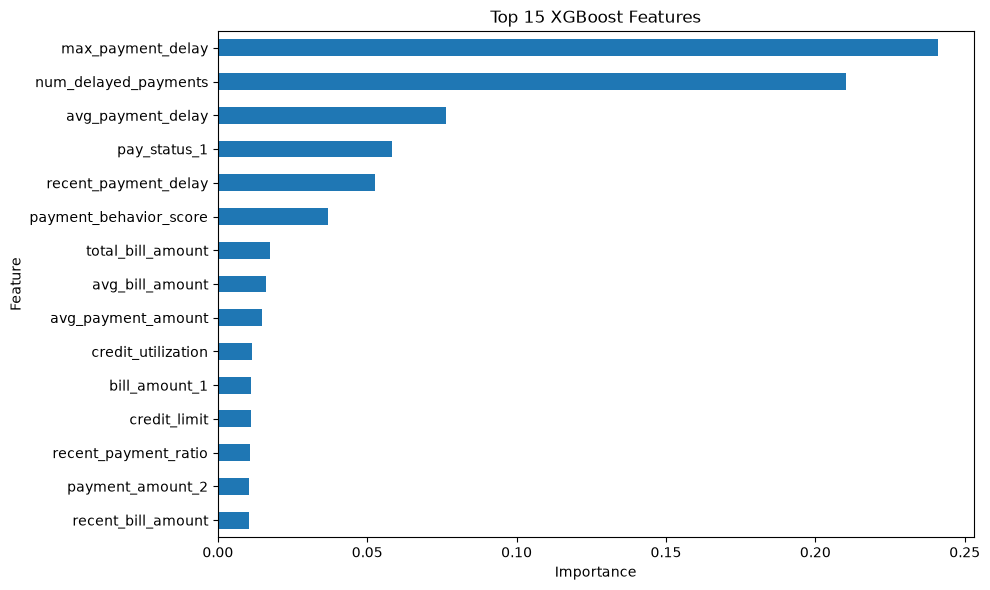

In [99]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 XGBoost Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# lets remove payment_behavior_score

In [100]:
feature_cols.remove("payment_behavior_score")

In [101]:
X = df[feature_cols]
y = df["payment_failure"]

In [102]:
print("Number of features:", len(feature_cols))
print("X shape:", X.shape)

Number of features: 37
X shape: (29965, 37)


In [103]:
from sklearn.model_selection import train_test_split

X = df[feature_cols]
y = df["payment_failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

X_train: (23972, 37)
X_test: (5993, 37)

Training target:
payment_failure
0    18668
1     5304
Name: count, dtype: int64

Testing target:
payment_failure
0    4667
1    1326
Name: count, dtype: int64


In [104]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Scale pos weight:", scale_pos_weight)

Scale pos weight: 3.519607843137255


In [105]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [106]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [107]:
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Accuracy : 0.7690639078925413
Precision: 0.4823170731707317
Recall   : 0.5965309200603318
F1 Score : 0.533378287255563
ROC-AUC  : 0.7733184701415962

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      4667
           1       0.48      0.60      0.53      1326

    accuracy                           0.77      5993
   macro avg       0.68      0.71      0.69      5993
weighted avg       0.79      0.77      0.78      5993



# Find the optimal risk threshold

In [109]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.20, 0.81, 0.05)

results = []

for threshold in thresholds:
    predictions = (xgb_prob >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0)
    })

threshold_df = pd.DataFrame(results)

threshold_df

,threshold,precision,recall,f1
0,0.20,0.283161,0.907994,0.431696
1,0.25,0.307755,0.858974,0.453153
2,0.30,0.335100,0.810709,0.474195
3,0.35,0.363570,0.749623,0.489655
4,0.40,0.397933,0.696833,0.506579
5,0.45,0.435937,0.644042,0.519939
6,0.50,0.482317,0.596531,0.533378
7,0.55,0.514706,0.554299,0.533769
8,0.60,0.542579,0.504525,0.522860
9,0.65,0.576077,0.453997,0.507803


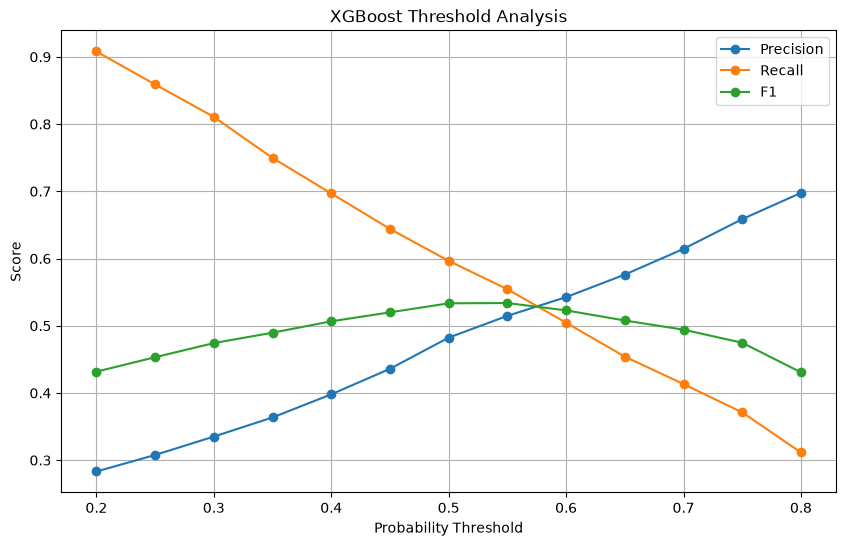

In [110]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("XGBoost Threshold Analysis")
plt.legend()
plt.grid(True)

plt.show()

In [112]:
import joblib

joblib.dump(
    xgb_model,
    "../ml/xgb_payment_failure_model.pkl"
)

['../ml/xgb_payment_failure_model.pkl']

In [113]:
joblib.dump(
    feature_cols,
    "../ml/feature_columns.pkl"
)

['../ml/feature_columns.pkl']

In [114]:
import os

print(os.path.exists("../ml/xgb_payment_failure_model.pkl"))
print(os.path.exists("../ml/feature_columns.pkl"))

True
True


In [115]:
import joblib

model = joblib.load("../ml/xgb_payment_failure_model.pkl")
feature_columns = joblib.load("../ml/feature_columns.pkl")

print("Model loaded:", type(model).__name__)
print("Number of features:", len(feature_columns))
print("Features:", feature_columns)

Model loaded: XGBClassifier
Number of features: 37
Features: ['credit_limit', 'gender', 'education', 'marital_status', 'age', 'pay_status_1', 'pay_status_2', 'pay_status_3', 'pay_status_4', 'pay_status_5', 'pay_status_6', 'bill_amount_1', 'bill_amount_2', 'bill_amount_3', 'bill_amount_4', 'bill_amount_5', 'bill_amount_6', 'payment_amount_1', 'payment_amount_2', 'payment_amount_3', 'payment_amount_4', 'payment_amount_5', 'payment_amount_6', 'num_delayed_payments', 'max_payment_delay', 'avg_payment_delay', 'recent_payment_delay', 'avg_bill_amount', 'avg_payment_amount', 'total_bill_amount', 'total_payment_amount', 'payment_to_bill_ratio', 'credit_utilization', 'payment_std', 'recent_payment_amount', 'recent_bill_amount', 'recent_payment_ratio']


In [116]:
customer = X_test.iloc[0]

print(customer)

credit_limit              50000.000000
gender                        2.000000
education                     3.000000
marital_status                1.000000
age                          43.000000
pay_status_1                  0.000000
pay_status_2                  0.000000
pay_status_3                  0.000000
pay_status_4                  0.000000
pay_status_5                  0.000000
pay_status_6                  0.000000
bill_amount_1             39177.000000
bill_amount_2             39607.000000
bill_amount_3             17070.000000
bill_amount_4             13038.000000
bill_amount_5              8904.000000
bill_amount_6              4740.000000
payment_amount_1           2000.000000
payment_amount_2           1500.000000
payment_amount_3           3500.000000
payment_amount_4            600.000000
payment_amount_5            500.000000
payment_amount_6           4000.000000
num_delayed_payments          0.000000
max_payment_delay             0.000000
avg_payment_delay        

In [117]:
customer_df = customer.to_frame().T

failure_probability = model.predict_proba(customer_df)[0][1]

print("Failure probability:", failure_probability)

Failure probability: 0.29412204


In [118]:
FAILURE_THRESHOLD = 0.50

predicted_failure = failure_probability >= FAILURE_THRESHOLD

print("Failure probability:", round(failure_probability, 4))
print("Predicted failure:", predicted_failure)

Failure probability: 0.2941
Predicted failure: False


In [119]:
if failure_probability < 0.30:
    risk_level = "LOW"
elif failure_probability < 0.60:
    risk_level = "MEDIUM"
else:
    risk_level = "HIGH"

print("Risk level:", risk_level)

Risk level: LOW


In [121]:
import joblib
import pandas as pd


MODEL_PATH = "../ml/xgb_payment_failure_model.pkl"
FEATURES_PATH = "../ml/feature_columns.pkl"

FAILURE_THRESHOLD = 0.50


# Load model and feature list
model = joblib.load(MODEL_PATH)
feature_columns = joblib.load(FEATURES_PATH)


def predict_payment_failure(customer_data):
    """
    Predict payment failure probability and risk level.
    """

    # Convert dictionary to DataFrame
    customer_df = pd.DataFrame([customer_data])

    # Ensure correct feature order
    customer_df = customer_df[feature_columns]

    # Predict probability of failure
    failure_probability = model.predict_proba(customer_df)[0][1]

    # ML decision threshold
    predicted_failure = failure_probability >= FAILURE_THRESHOLD

    # Business risk level
    if failure_probability < 0.30:
        risk_level = "LOW"
    elif failure_probability < 0.60:
        risk_level = "MEDIUM"
    else:
        risk_level = "HIGH"

    return {
        "failure_probability": round(float(failure_probability), 4),
        "predicted_failure": bool(predicted_failure),
        "risk_level": risk_level
    }

In [122]:
customer_data = X_test.iloc[0].to_dict()

result = predict_payment_failure(customer_data)

print(result)

{'failure_probability': 0.2941, 'predicted_failure': False, 'risk_level': 'LOW'}


In [123]:
OUTPUT_PATH = "../data/processed/customer_features.csv"

df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved to: {OUTPUT_PATH}")
print("Shape:", df.shape)

Saved to: ../data/processed/customer_features.csv
Shape: (29965, 42)


In [124]:
import os

print(os.path.exists(OUTPUT_PATH))

True


In [125]:
processed_df = pd.read_csv(OUTPUT_PATH)

print(processed_df.shape)
print(processed_df.head())

(29965, 42)
   credit_limit  gender  education  marital_status  age  pay_status_1  \
0         20000       2          2               1   24             2   
1        120000       2          2               2   26            -1   
2         90000       2          2               2   34             0   
3         50000       2          2               1   37             0   
4         50000       1          2               1   57            -1   

   pay_status_2  pay_status_3  pay_status_4  pay_status_5  pay_status_6  \
0             2            -1            -1            -2            -2   
1             2             0             0             0             2   
2             0             0             0             0             0   
3             0             0             0             0             0   
4             0            -1             0             0             0   

   bill_amount_1  bill_amount_2  bill_amount_3  bill_amount_4  bill_amount_5  \
0           3913  